In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load and preprocess
df = pd.read_csv("../../Data/train/maintenance_records.csv")
df["maintenance_date"] = pd.to_datetime(df["maintenance_date"])
df = df.sort_values(by=["printer_id", "maintenance_date"])

# Feature engineering
df["days_since_last"] = df.groupby("printer_id")["maintenance_date"].diff().dt.days
df["maintenance_count"] = df.groupby("printer_id").cumcount() + 1
df["avg_cost"] = df.groupby("printer_id")["cost"].transform("mean")
df["days_since_last"] = df["days_since_last"].fillna(df["days_since_last"].median())
df["maintenance_needed_soon"] = (df["days_since_last"] < 30).astype(int)

# One-hot encode issue types
df = pd.get_dummies(df, columns=["description"], prefix="issue")

# Drop irrelevant columns
df = df.drop(columns=["record_id", "maintenance_date", "technician"])

# Split data into training (historical) and testing (latest entry per printer)
latest_entries = df.groupby("printer_id").tail(1)
historical_entries = df.drop(latest_entries.index)

X_train = historical_entries.drop(columns=["maintenance_needed_soon", "printer_id"])
y_train = historical_entries["maintenance_needed_soon"]

X_test = latest_entries.drop(columns=["maintenance_needed_soon", "printer_id"])
y_test = latest_entries["maintenance_needed_soon"]
printer_ids_test = latest_entries["printer_id"].reset_index(drop=True)

# Models to apply
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train, evaluate and predict
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate performance
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Identify printers predicted to need maintenance soon
    result_df = pd.DataFrame({
        "printer_id": printer_ids_test,
        "maintenance_predicted": y_pred
    })
    at_risk_printers = result_df[result_df["maintenance_predicted"] == 1]["printer_id"].unique()
    print("Printers predicted to need maintenance soon:")
    print(at_risk_printers)



=== Random Forest ===
Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00         4

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25

Printers predicted to need maintenance soon:
['PRN006' 'PRN017' 'PRN020' 'PRN021']

=== Gradient Boosting ===
Accuracy: 1.00
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00         4

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25

Printers predicted to need maintenance soon:
['PRN006' 'PRN017' 'PRN020' 'PRN021']


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, classification_report

# Load CSV files (update the paths below)
maintenance_df = pd.read_csv(r"c:\Users\Hp admin\Desktop\powerbi\maintainance_records.csv")
print_jobs_df = pd.read_csv(r"c:\Users\Hp admin\Desktop\powerbi\print_jobs.csv")  # Replace with actual print job CSV

# Preprocessing
maintenance_df['maintenance_date'] = pd.to_datetime(maintenance_df['maintenance_date'])
print_jobs_df['print_time'] = pd.to_datetime(print_jobs_df['print_time'])

maintenance_df = maintenance_df.sort_values(by=['printer_id', 'maintenance_date'])
maintenance_df['days_since_last_maintenance'] = maintenance_df.groupby('printer_id')['maintenance_date'].diff().dt.days

printer_job_stats = print_jobs_df.groupby('printer_id').agg({
    'job_id': 'count',
    'page_count': ['mean', 'sum'],
    'duplex': 'mean',
    'color': 'mean',
    'cost': ['mean', 'sum'],
    'print_time': ['min', 'max']
})
printer_job_stats.columns = ['_'.join(col).strip() for col in printer_job_stats.columns.values]
printer_job_stats = printer_job_stats.reset_index()
printer_job_stats['active_days'] = (printer_job_stats['print_time_max'] - printer_job_stats['print_time_min']).dt.days
printer_job_stats['jobs_per_day'] = printer_job_stats['job_id_count'] / printer_job_stats['active_days'].replace(0, 1)

maintenance_summary = maintenance_df.groupby('printer_id').agg({
    'record_id': 'count',
    'cost': 'sum',
    'days_since_last_maintenance': 'mean'
}).rename(columns={
    'record_id': 'maintenance_count',
    'cost': 'total_maintenance_cost',
    'days_since_last_maintenance': 'avg_days_between_maintenance'
}).reset_index()

printer_summary = pd.merge(printer_job_stats, maintenance_summary, on='printer_id', how='left')

# ----- Regression: Predict avg_days_between_maintenance -----
regression_data = printer_summary.dropna(subset=['avg_days_between_maintenance'])

regression_features = [
    'job_id_count', 'page_count_mean', 'page_count_sum',
    'duplex_mean', 'color_mean', 'cost_mean', 'cost_sum', 'jobs_per_day'
]
X_reg = regression_data[regression_features]
y_reg = regression_data['avg_days_between_maintenance']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)
reg_mae = mean_absolute_error(y_test_reg, y_pred_reg)

# ----- Classification: Predict bad printers -----
printer_summary['bad_printer'] = (printer_summary['maintenance_count'] > 8).astype(int)

printer_summary.fillna({
    'maintenance_count': 0,
    'total_maintenance_cost': 0,
    'avg_days_between_maintenance': printer_summary['avg_days_between_maintenance'].mean()
}, inplace=True)

classification_features = regression_features + ['maintenance_count', 'total_maintenance_cost']
X_cls = printer_summary[classification_features]
y_cls = printer_summary['bad_printer']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

cls_model = RandomForestClassifier(n_estimators=100, random_state=42)
cls_model.fit(X_train_cls, y_train_cls)
y_pred_cls = cls_model.predict(X_test_cls)
cls_report = classification_report(y_test_cls, y_pred_cls, output_dict=True)

reg_feature_importance = dict(zip(regression_features, reg_model.feature_importances_))
cls_feature_importance = dict(zip(classification_features, cls_model.feature_importances_))

print("Mean Absolute Error (Regression):", reg_mae)
print("Classification Report:", classification_report(y_test_cls, y_pred_cls))
print("Top Regression Features:", reg_feature_importance)
print("Top Classification Features:", cls_feature_importance)


# Detect bad printers
bad_printers = printer_summary[printer_summary['bad_printer'] == 1][['printer_id', 'maintenance_count', 'total_maintenance_cost', 'job_id_count']]
print(" BAD PRINTERS DETECTED:")
print(bad_printers)


Mean Absolute Error (Regression): 40.868666666666655
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

Top Regression Features: {'job_id_count': np.float64(0.061125633036743704), 'page_count_mean': np.float64(0.1454549378399077), 'page_count_sum': np.float64(0.11806056007008651), 'duplex_mean': np.float64(0.12453638572091347), 'color_mean': np.float64(0.13971872881441919), 'cost_mean': np.float64(0.1371814285953093), 'cost_sum': np.float64(0.06511761779396799), 'jobs_per_day': np.float64(0.2088047081286521)}
Top Classification Features: {'job_id_count': np.float64(0.0), 'page_count_mean': np.float64(0.0), 'page_count_sum': np.float64(0.0), 'duplex_mean': np.float64(0.0), 'color_mean': np.float64(0.0), 'cost_mean': np.float64(0.0), 'cost_sum': n

📊 Classification Report:
              precision    recall  f1-score   support

         Bad       1.00      1.00      1.00         1
        Good       1.00      1.00      1.00         2
    Moderate       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



C:\Users\Hp admin\AppData\Local\Temp\ipykernel_13716\4041006587.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Printer Status', y='Count', data=status_counts, palette={'Good': 'green', 'Moderate': 'orange', 'Bad': 'red'})


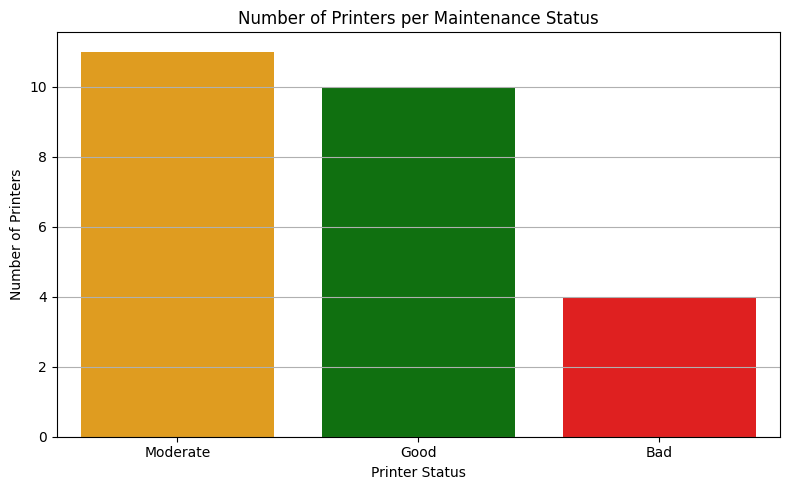


🔧 BAD PRINTERS (Avg Maintenance Gap < 30 days):
   printer_id  gap_days_mean
5      PRN006      10.000000
16     PRN017      13.833333
19     PRN020      21.333333
20     PRN021      19.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Load data
df = pd.read_csv(r"c:\Users\Hp admin\Desktop\powerbi\maintainance_records.csv")  # <-- Update this path

# Preprocessing
df['maintenance_date'] = pd.to_datetime(df['maintenance_date'])
df = df.sort_values(by=['printer_id', 'maintenance_date'])
df['gap_days'] = df.groupby('printer_id')['maintenance_date'].diff().dt.days

# Feature aggregation
summary = df.groupby('printer_id').agg({
    'gap_days': ['mean', 'min', 'max', 'count'],
    'cost': ['mean', 'sum', 'count']
})
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()

# Labeling based on average maintenance gap
def label_gap(gap):
    if gap < 30:
        return 'Bad'
    elif gap < 90:
        return 'Moderate'
    else:
        return 'Good'

summary['status'] = summary['gap_days_mean'].apply(label_gap)

# Encode labels
le = LabelEncoder()
summary['status_label'] = le.fit_transform(summary['status'])

# Prepare features and labels
features = [col for col in summary.columns if col not in ['printer_id', 'status', 'status_label']]
X = summary[features]
y = summary['status_label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict full dataset
summary['predicted_status_label'] = clf.predict(X)
summary['predicted_status'] = le.inverse_transform(summary['predicted_status_label'])

# Evaluation
print("📊 Classification Report:")
print(classification_report(y_test, clf.predict(X_test), target_names=le.classes_))

# ---- Bar Chart: Printer Counts ----
status_counts = summary['predicted_status'].value_counts().reset_index()
status_counts.columns = ['Printer Status', 'Count']

plt.figure(figsize=(8, 5))
sns.barplot(x='Printer Status', y='Count', data=status_counts, palette={'Good': 'green', 'Moderate': 'orange', 'Bad': 'red'})
plt.title("Number of Printers per Maintenance Status")
plt.ylabel("Number of Printers")
plt.xlabel("Printer Status")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ---- Print Bad Printers ----
bad_printers = summary[summary['predicted_status'] == 'Bad'][['printer_id', 'gap_days_mean']]
print("\n🔧 BAD PRINTERS (Avg Maintenance Gap < 30 days):")
print(bad_printers)



📊 Classification Report:
              precision    recall  f1-score   support

         Bad       1.00      1.00      1.00         2
    Moderate       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



C:\Users\Hp admin\AppData\Local\Temp\ipykernel_13716\459546517.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Printer Status', y='Count', data=status_counts, palette={'Good': 'green', 'Moderate': 'orange', 'Bad': 'red'})


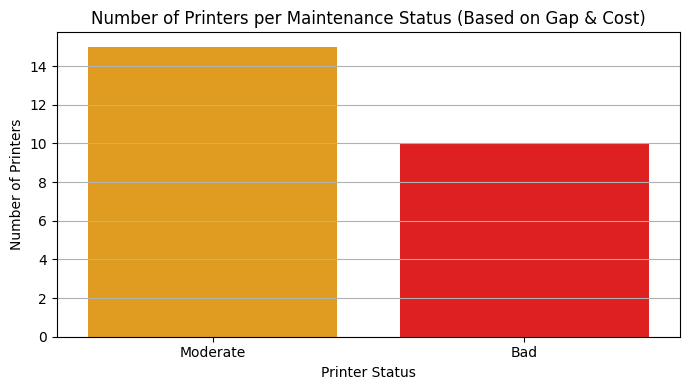


🔧 BAD PRINTERS (Gap < 30 days OR Cost > 2000):
   printer_id  gap_days_mean  cost_sum
3      PRN004      60.833333      2594
5      PRN006      10.000000      1785
11     PRN012      62.333333      2112
12     PRN013      61.666667      2031
14     PRN015      62.333333      2344
16     PRN017      13.833333      1815
17     PRN018      62.166667      2286
19     PRN020      21.333333      1236
20     PRN021      19.000000      1272
22     PRN023      61.000000      2158


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Load data
df = pd.read_csv(r"c:\Users\Hp admin\Desktop\powerbi\maintainance_records.csv")  # <-- Update if needed

# Preprocessing
df['maintenance_date'] = pd.to_datetime(df['maintenance_date'])
df = df.sort_values(by=['printer_id', 'maintenance_date'])
df['gap_days'] = df.groupby('printer_id')['maintenance_date'].diff().dt.days

# Feature aggregation
summary = df.groupby('printer_id').agg({
    'gap_days': ['mean', 'min', 'max', 'count'],
    'cost': ['mean', 'sum', 'count']
})
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()

# Labeling based on both maintenance gap and cost
def label_printer(gap, cost):
    if gap < 30 or cost > 2000:
        return 'Bad'
    elif gap < 90 or cost > 600:
        return 'Moderate'
    else:
        return 'Good'

summary['status'] = summary.apply(lambda row: label_printer(row['gap_days_mean'], row['cost_sum']), axis=1)

# Encode status labels
le = LabelEncoder()
summary['status_label'] = le.fit_transform(summary['status'])

# Features and label
features = ['gap_days_mean', 'gap_days_min', 'gap_days_max', 'gap_days_count',
            'cost_mean', 'cost_sum', 'cost_count']
X = summary[features]
y = summary['status_label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict full dataset
summary['predicted_status_label'] = clf.predict(X)
summary['predicted_status'] = le.inverse_transform(summary['predicted_status_label'])

# Classification report (with correction for present labels only)
present_labels = sorted(y_test.unique())
present_classes = le.inverse_transform(present_labels)

print("\n📊 Classification Report:")
print(classification_report(
    y_test,
    clf.predict(X_test),
    labels=present_labels,
    target_names=present_classes
))

# Plot printer status count
status_counts = summary['predicted_status'].value_counts().reset_index()
status_counts.columns = ['Printer Status', 'Count']

plt.figure(figsize=(7, 4))
sns.barplot(x='Printer Status', y='Count', data=status_counts, palette={'Good': 'green', 'Moderate': 'orange', 'Bad': 'red'})
plt.title("Number of Printers per Maintenance Status (Based on Gap & Cost)")
plt.ylabel("Number of Printers")
plt.xlabel("Printer Status")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Print Bad Printers
bad_printers = summary[summary['predicted_status'] == 'Bad'][['printer_id', 'gap_days_mean', 'cost_sum']]
print("\n🔧 BAD PRINTERS (Gap < 30 days OR Cost > 2000):")
print(bad_printers)
